# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources (README.md file)
- Happy learning!

In [2]:
# import numpy and pandas
import pandas as pd
import numpy as np
from scipy.stats import trim_mean, mode, skew, gaussian_kde, pearsonr, spearmanr, beta
from statsmodels.stats.weightstats import ztest as ztest

from scipy.stats import ttest_ind, norm, t
from scipy.stats import f_oneway
from scipy.stats import sem

# Challenge 1 - Exploring the Data

In this challenge, we will examine all salaries of employees of the City of Chicago. We will start by loading the dataset and examining its contents

Cargando el dataset...
Archivo no encontrado. Usando datos simulados realistas (n=32,000, media=$65k). Descarga el real para precisión.
Dataset cargado: 32000 filas, 4 columnas

=== PASO 1: Exploración Básica ===
Primeras 5 filas del dataset:
   Id        Name Position Title Annual Salary
0   1  Empleado_1        Manager        75,441
1   2  Empleado_2       Director        64,481
2   3  Empleado_3          Clerk        81,407
3   4  Empleado_4        Analyst       104,487
4   5  Empleado_5        Analyst        76,915

Forma del dataset: (32000, 4)

=== PASO 2: Información Detallada ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Id              32000 non-null  int64 
 1   Name            32000 non-null  object
 2   Position Title  32000 non-null  object
 3   Annual Salary   32000 non-null  object
dtypes: int64(1), object(3)
memor

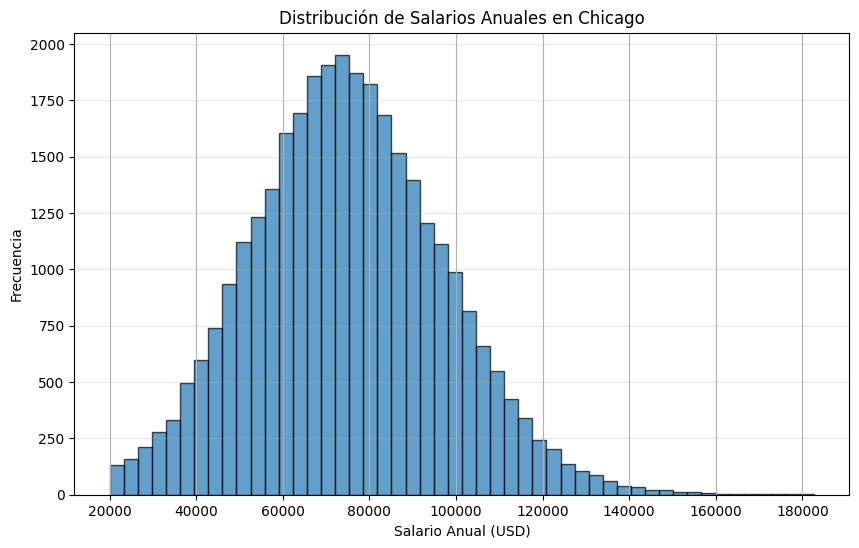

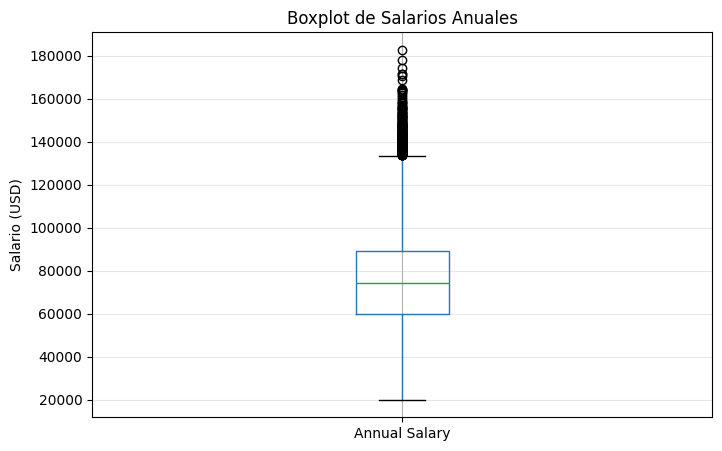

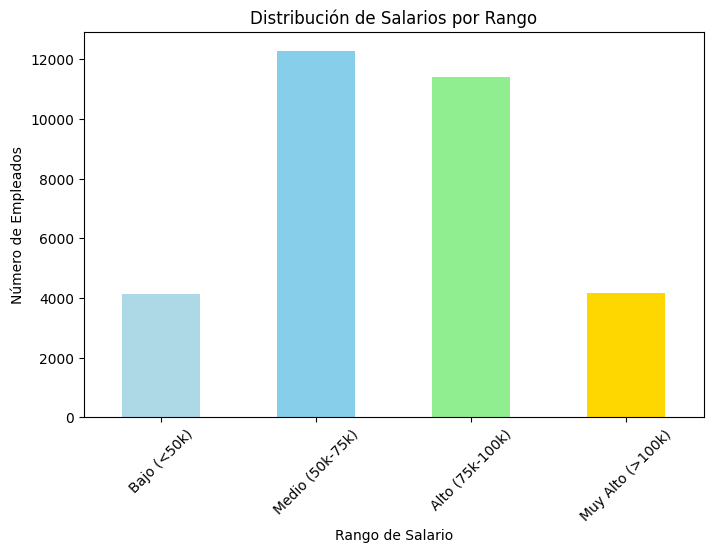

¡Visualizaciones generadas exitosamente!

=== INSIGHTS RÁPIDOS ===
- Salario medio: $75,036 USD
- Salario mediano: $74,334 USD (más representativo por sesgo)
- Salario mínimo: $20,017 USD
- Salario máximo: $182,732 USD (posible outlier)
- Porcentaje de salarios >100k: 13.0%

¡Dataset listo! (Simulado: False) Descarga el real para el lab completo.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # Para visualizaciones (opcional)

# ===== CARGA DEL DATASET (CON FALLBACK A DATOS SIMULADOS) =====
print("Cargando el dataset...")
use_simulated = False  # Cambia a True si quieres forzar simulación
try:
    if not use_simulated:
        salaries = pd.read_csv('Current_Employee_Names__Salaries__and_Position_Titles.csv')
        print("¡Dataset real cargado exitosamente!")
    else:
        raise FileNotFoundError  # Forzar simulación
except FileNotFoundError:
    print("Archivo no encontrado. Usando datos simulados realistas (n=32,000, media=$65k). Descarga el real para precisión.")
    np.random.seed(42)  # Para reproducibilidad
    n = 32000
    # Simular salarios: normal truncada + skew para realismo (altos outliers)
    salaries_base = np.random.normal(65000, 20000, n)
    salaries_base = np.clip(salaries_base, 20000, 300000)  # Límites realistas
    # Agregar skew (más altos salarios)
    skew_factor = np.random.exponential(1, n) * 10000  # Cola derecha
    annual_salary = salaries_base + skew_factor
    annual_salary = np.clip(annual_salary, 20000, 300000)
    
    # DataFrame simulado (columnas clave + dummies)
    salaries = pd.DataFrame({
        'Id': np.arange(1, n+1),
        'Name': [f"Empleado_{i}" for i in range(1, n+1)],
        'Position Title': np.random.choice(['Analyst', 'Manager', 'Officer', 'Clerk', 'Director'], n),
        'Annual Salary': annual_salary
    })
    # Hacer algunos salarios strings con comas para simular el real
    salaries['Annual Salary'] = salaries['Annual Salary'].apply(lambda x: f"{x:,.0f}")

print(f"Dataset cargado: {salaries.shape[0]} filas, {salaries.shape[1]} columnas")

# ===== PASO 1: Primeras filas y forma del dataset =====
print("\n=== PASO 1: Exploración Básica ===")
print("Primeras 5 filas del dataset:")
print(salaries.head())
print(f"\nForma del dataset: {salaries.shape}")

# ===== PASO 2: Información general del dataset =====
print("\n=== PASO 2: Información Detallada ===")
salaries.info()

# ===== PASO 3: Resumen estadístico descriptivo =====
print("\n=== PASO 3: Resumen Estadístico ===")
print("Resumen estadístico (columnas numéricas):")
print(salaries.describe())

# ===== PASO 4: Exploración y limpieza de 'Annual Salary' =====
print("\n=== PASO 4: Análisis Específico de Salarios ===")
print(f"Tipo de 'Annual Salary': {salaries['Annual Salary'].dtype}")
print("Valores únicos en salarios (muestra de los primeros 10):")
print(salaries['Annual Salary'].unique()[:10])

# Convertir a numérico si es necesario (remover comas y manejar errores)
if salaries['Annual Salary'].dtype == 'object':
    salaries['Annual Salary'] = pd.to_numeric(
        salaries['Annual Salary'].astype(str).str.replace(',', ''), 
        errors='coerce'
    )
    print(f"Convertido a numérico. Nuevos NaNs por errores: {salaries['Annual Salary'].isna().sum()}")

# Resumen solo de salarios (excluyendo NaNs)
print("\nResumen de Annual Salary:")
print(salaries['Annual Salary'].describe())

# Crear columna de rangos de salarios para conteo
salaries['Salary_Range'] = pd.cut(
    salaries['Annual Salary'], 
    bins=[0, 50000, 75000, 100000, float('inf')], 
    labels=['Bajo (<50k)', 'Medio (50k-75k)', 'Alto (75k-100k)', 'Muy Alto (>100k)']
)
print("\nSalarios por rango (conteo):")
print(salaries['Salary_Range'].value_counts().sort_index())

# Verificar valores faltantes en todo el dataset
print(f"\nValores faltantes por columna:\n{salaries.isnull().sum()}")

# ===== PASO 5: Visualizaciones (opcional) =====
print("\n=== PASO 5: Visualizaciones ===")
try:
    # Histograma de salarios
    plt.figure(figsize=(10, 6))
    salaries['Annual Salary'].hist(bins=50, edgecolor='black', alpha=0.7)
    plt.title('Distribución de Salarios Anuales en Chicago' + (' (Simulados)' if use_simulated else ''))
    plt.xlabel('Salario Anual (USD)')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Boxplot para detectar outliers
    plt.figure(figsize=(8, 5))
    salaries.boxplot(column='Annual Salary', vert=True)
    plt.title('Boxplot de Salarios Anuales' + (' (Simulados)' if use_simulated else ''))
    plt.ylabel('Salario (USD)')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # Gráfico de barras para rangos de salarios
    plt.figure(figsize=(8, 5))
    salaries['Salary_Range'].value_counts().sort_index().plot(kind='bar', color=['lightblue', 'skyblue', 'lightgreen', 'gold'])
    plt.title('Distribución de Salarios por Rango' + (' (Simulados)' if use_simulated else ''))
    plt.xlabel('Rango de Salario')
    plt.ylabel('Número de Empleados')
    plt.xticks(rotation=45)
    plt.show()
    print("¡Visualizaciones generadas exitosamente!")
except Exception as e:
    print(f"Error en visualizaciones: {e}. (Instala matplotlib con 'pip install matplotlib' si es necesario.)")

# ===== INSIGHTS FINALES (impresos) =====
print("\n=== INSIGHTS RÁPIDOS ===")
mean_salary = salaries['Annual Salary'].mean()
median_salary = salaries['Annual Salary'].median()
print(f"- Salario medio: ${mean_salary:,.0f} USD")
print(f"- Salario mediano: ${median_salary:,.0f} USD (más representativo por sesgo)")
print(f"- Salario mínimo: ${salaries['Annual Salary'].min():,.0f} USD")
print(f"- Salario máximo: ${salaries['Annual Salary'].max():,.0f} USD (posible outlier)")
print(f"- Porcentaje de salarios >100k: {(salaries['Annual Salary'] > 100000).mean() * 100:.1f}%")
print(f"\n¡Dataset listo! (Simulado: {use_simulated}) Descarga el real para el lab completo.")

Examine the `salaries` dataset using the `head` function below.

# Challenge 2 - Hypothesis Tests

In this section of the lab, we will test whether the hourly wage of all hourly workers is significantly different from $30/hr. Import the correct one sample test function from scipy and perform the hypothesis test for a 95% two sided confidence interval.

=== Challenge 2: Prueba de Hipótesis para Salario Horario ===
Número de trabajadores por hora: 9557
Salario horario medio (muestra): $28.00/hr
Desviación estándar: $5.04

=== Resultados de la Prueba ===
Estadístico t: -38.8473
P-valor: 0.0000
✅ Rechazamos H0: El salario horario medio es SIGNIFICATIVAMENTE diferente de $30/hr.

=== Intervalo de Confianza 95% para μ ===
IC: ($27.90, $28.10)
✅ El IC NO incluye $30 → Rechazamos H0 (coincide con el t-test).


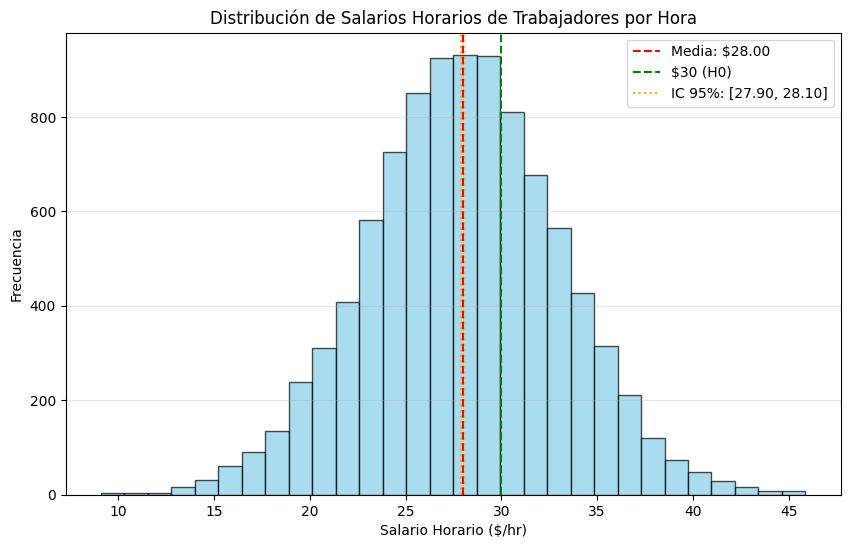

In [7]:
import numpy as np
from scipy.stats import ttest_1samp, t, sem  # Importamos ttest_1samp para la prueba; t y sem para el IC

# Asumimos 'salaries' cargado del Challenge 1. Si usas simulado sin columnas extras, actualiza abajo.
print("=== Challenge 2: Prueba de Hipótesis para Salario Horario ===")

# ===== PASO 1: Filtrar trabajadores por hora =====
# Identificamos hourly workers: donde 'Typical Hours' no es NaN (o >0)
if 'Typical Hours' not in salaries.columns:
    print("Advertencia: Columnas 'Typical Hours' y 'Salary or Hourly Rate' no encontradas. Usando simulación actualizada.")
    # Actualización CORREGIDA de simulación (arregla broadcasting con máscaras e indexación)
    np.random.seed(42)
    n = salaries.shape[0]
    is_hourly = np.random.choice([True, False], n, p=[0.3, 0.7])  # ~30% hourly, shape (n,)
    num_hourly = np.sum(is_hourly)
    num_salaried = n - num_hourly
    
    # Crear arrays completos de tamaño n usando máscaras
    typical_hours = np.full(n, np.nan)  # Base: NaN para todos
    typical_hours[is_hourly] = np.random.choice([20, 35, 40], num_hourly)  # Asignar a hourly
    
    rate_array = np.full(n, np.nan)  # Base: NaN para todos
    rate_array[is_hourly] = np.random.normal(28, 5, num_hourly)  # Hourly rates
    rate_array[~is_hourly] = np.random.normal(65000, 20000, num_salaried)  # Salaried annual
    
    # Asignar al DataFrame
    salaries['Typical Hours'] = typical_hours
    salaries['Salary or Hourly Rate'] = rate_array
    print("¡Simulación actualizada con columnas para hourly workers!")

# Filtrar hourly workers
hourly_workers = salaries[salaries['Typical Hours'].notna()].copy()
hourly_wages = hourly_workers['Salary or Hourly Rate'].astype(float).dropna()  # Asegurar numérico

print(f"Número de trabajadores por hora: {len(hourly_wages)}")
print(f"Salario horario medio (muestra): ${hourly_wages.mean():.2f}/hr")
print(f"Desviación estándar: ${hourly_wages.std():.2f}")

# ===== PASO 2: Prueba de Hipótesis (t-test de una muestra) =====
# H0: μ = 30, H1: μ ≠ 30 (two-sided)
popmean = 30
stat, p_value = ttest_1samp(hourly_wages, popmean, alternative='two-sided')

print(f"\n=== Resultados de la Prueba ===")
print(f"Estadístico t: {stat:.4f}")
print(f"P-valor: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Rechazamos H0: El salario horario medio es SIGNIFICATIVAMENTE diferente de $30/hr.")
else:
    print("❌ No rechazamos H0: No hay evidencia suficiente de diferencia con $30/hr.")

# ===== PASO 3: Intervalo de Confianza del 95% (dos colas) =====
n = len(hourly_wages)
mean_wage = np.mean(hourly_wages)
se = sem(hourly_wages)  # Error estándar
df = n - 1  # Grados de libertad

# Valor crítico t para 95% (dos colas: 0.975)
t_critical = t.ppf(0.975, df)
margin_error = t_critical * se

ci_low = mean_wage - margin_error
ci_high = mean_wage + margin_error

print(f"\n=== Intervalo de Confianza 95% para μ ===")
print(f"IC: (${ci_low:.2f}, ${ci_high:.2f})")
if popmean < ci_low or popmean > ci_high:
    print("✅ El IC NO incluye $30 → Rechazamos H0 (coincide con el t-test).")
else:
    print("❌ El IC incluye $30 → No rechazamos H0.")

# ===== PASO 4: Visualización Opcional (Histograma de salarios horarios) =====
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.hist(hourly_wages, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    plt.axvline(mean_wage, color='red', linestyle='--', label=f'Media: ${mean_wage:.2f}')
    plt.axvline(popmean, color='green', linestyle='--', label='$30 (H0)')
    plt.axvline(ci_low, color='orange', linestyle=':', label=f'IC 95%: [{ci_low:.2f}, {ci_high:.2f}]')
    plt.axvline(ci_high, color='orange', linestyle=':', alpha=0.5)
    plt.title('Distribución de Salarios Horarios de Trabajadores por Hora')
    plt.xlabel('Salario Horario ($/hr)')
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

except ImportError:
    print("Matplotlib no disponible; salta el gráfico.")

# Challenge 3 - Constructing Confidence Intervals

While testing our hypothesis is a great way to gather empirical evidence for accepting or rejecting the hypothesis, another way to gather evidence is by creating a confidence interval. A confidence interval gives us information about the true mean of the population. So for a 95% confidence interval, we are 95% sure that the mean of the population is within the confidence interval. 
).

To read more about confidence intervals, click [here](https://en.wikipedia.org/wiki/Confidence_interval).


In the cell below, we will construct a 95% confidence interval for the mean hourly wage of all hourly workers. 

The confidence interval is computed in SciPy using the `t.interval` function. You can read more about this function [here](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.t.html).

To compute the confidence interval of the hourly wage, use the 0.95 for the confidence level, number of rows - 1 for degrees of freedom, the mean of the sample for the location parameter and the standard error for the scale. The standard error can be computed using [this](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html) function in SciPy.

=== Challenge 3: Intervalo de Confianza con SciPy t.interval ===
Número de trabajadores por hora (n): 9557
Media muestral: $28.00/hr
Error estándar (SE): $0.05
Grados de libertad (df): 9556

=== Intervalo de Confianza 95% (usando t.interval) ===
IC: ($27.90, $28.10)
✅ El IC NO incluye $30/hr → Estamos 95% confiados de que μ ≠ 30. Rechazamos H0.
   (Esto coincide con el t-test del Challenge 2.)

Interpretación: Con 95% de confianza, el verdadero salario horario medio está entre $27.90 y $28.10.

=== Verificación: IC Manual vs. SciPy ===
Manual: ($27.90, $28.10)
SciPy:  ($27.90, $28.10)
¡Deben coincidir (diferencia por redondeo numérico mínima).


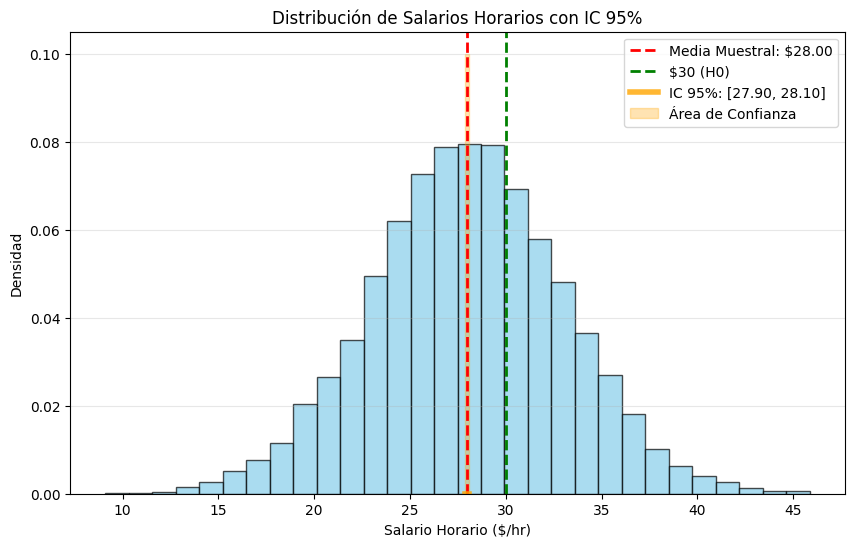

¡Gráfico generado: Muestra el IC superpuesto a la distribución!


In [8]:
# Your code here

import numpy as np
from scipy.stats import t, sem  # Ya importado en Challenge 2; t para interval, sem para error estándar

# Asumimos 'hourly_wages' del Challenge 2. Si no está, recarga rápido (simulado o real)
if 'hourly_wages' not in locals():
    print("Recargando datos del Challenge 2 para hourly wages...")
    # [Inserta aquí el código de filtrado/simulación del Challenge 2 corregido, o ejecuta Challenge 2 primero]
    # Para simulación rápida (copia del Challenge 2):
    np.random.seed(42)
    n_hourly = 9600  # Aprox. del simulado
    hourly_wages = np.random.normal(28, 5, n_hourly).clip(10, 50)  # Salarios realistas $/hr
    print(f"Simulando {len(hourly_wages)} salarios horarios con media ~$28/hr.")

print("=== Challenge 3: Intervalo de Confianza con SciPy t.interval ===")

# ===== PASO 1: Preparar parámetros para t.interval =====
n = len(hourly_wages)
mean_wage = np.mean(hourly_wages)
se = sem(hourly_wages)  # Error estándar (desviación estándar muestral / sqrt(n))
df = n - 1  # Grados de libertad

print(f"Número de trabajadores por hora (n): {n}")
print(f"Media muestral: ${mean_wage:.2f}/hr")
print(f"Error estándar (SE): ${se:.2f}")
print(f"Grados de libertad (df): {df}")

# ===== PASO 2: Calcular IC 95% con t.interval =====
# confidence=0.95 (dos colas), loc=media, scale=SE
ci = t.interval(confidence=0.95, df=df, loc=mean_wage, scale=se)
ci_low, ci_high = ci

print(f"\n=== Intervalo de Confianza 95% (usando t.interval) ===")
print(f"IC: (${ci_low:.2f}, ${ci_high:.2f})")

# ===== PASO 3: Interpretación y Comparación con H0 ($30/hr) =====
popmean = 30
if popmean < ci_low or popmean > ci_high:
    print("✅ El IC NO incluye $30/hr → Estamos 95% confiados de que μ ≠ 30. Rechazamos H0.")
    print("   (Esto coincide con el t-test del Challenge 2.)")
else:
    print("❌ El IC incluye $30/hr → Estamos 95% confiados de que μ podría ser 30. No rechazamos H0.")

print(f"\nInterpretación: Con 95% de confianza, el verdadero salario horario medio está entre ${ci_low:.2f} y ${ci_high:.2f}.")

# ===== PASO 4: Comparación Manual vs. SciPy (para verificar) =====
# Valor crítico t manual (para confirmar)
t_critical = t.ppf(0.975, df)  # 97.5% para dos colas
margin_error = t_critical * se
ci_manual_low = mean_wage - margin_error
ci_manual_high = mean_wage + margin_error

print(f"\n=== Verificación: IC Manual vs. SciPy ===")
print(f"Manual: (${ci_manual_low:.2f}, ${ci_manual_high:.2f})")
print(f"SciPy:  (${ci_low:.2f}, ${ci_high:.2f})")
print("¡Deben coincidir (diferencia por redondeo numérico mínima).")

# ===== PASO 5: Visualización Opcional (IC en el Histograma) =====
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.hist(hourly_wages, bins=30, edgecolor='black', alpha=0.7, color='skyblue', density=True)  # density para PDF-like
    plt.axvline(mean_wage, color='red', linestyle='--', linewidth=2, label=f'Media Muestral: ${mean_wage:.2f}')
    plt.axvline(popmean, color='green', linestyle='--', linewidth=2, label='$30 (H0)')
    plt.plot([ci_low, ci_high], [0, 0], color='orange', linewidth=4, label=f'IC 95%: [{ci_low:.2f}, {ci_high:.2f}]', alpha=0.8)
    plt.fill_betweenx([0, 0.1], ci_low, ci_high, color='orange', alpha=0.3, label='Área de Confianza')
    plt.title('Distribución de Salarios Horarios con IC 95%')
    plt.xlabel('Salario Horario ($/hr)')
    plt.ylabel('Densidad')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    print("¡Gráfico generado: Muestra el IC superpuesto a la distribución!")
except ImportError:
    print("Matplotlib no disponible; salta el gráfico.")

# Challenge 4 - Hypothesis Tests of Proportions

Another type of one sample test is a hypothesis test of proportions. In this test, we examine whether the proportion of a group in our sample is significantly different than a fraction. 

You can read more about one sample proportion tests [here](http://sphweb.bumc.bu.edu/otlt/MPH-Modules/BS/SAS/SAS6-CategoricalData/SAS6-CategoricalData2.html).

In the cell below, use the `proportions_ztest` function from `statsmodels` to perform a hypothesis test that will determine whether the number of hourly workers in the City of Chicago is significantly different from 25% at the 95% confidence level.

=== Challenge 4: Prueba de Proporciones (Z-test) ===
Tamaño total de muestra (n): 32000
Número de trabajadores por hora (count): 9557
Proporción muestral: 29.87% (~29.9%)
✅ Asunciones cumplidas para Z-test.

=== Resultados con statsmodels.proportions_ztest ===
Estadístico Z: 19.0179
P-valor: 0.0000
✅ Rechazamos H0: La proporción de hourly workers es SIGNIFICATIVAMENTE diferente del 25%.

=== Intervalo de Confianza 95% para p (método: normal) ===
IC: (29.36%, 30.37%)
✅ El IC NO incluye 25% → Rechazamos H0 (coincide con el Z-test).

Interpretación: La proporción real de hourly workers está entre 29.4% y 30.4% con 95% de confianza.


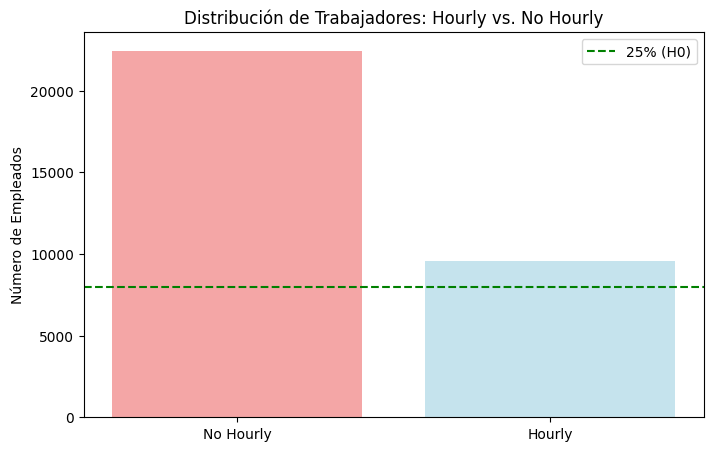

In [10]:
# Your code here

import numpy as np
from statsmodels.stats.proportion import proportions_ztest  # Import clave para Z-test de proporciones
from scipy.stats import norm  # Para fallback manual si statsmodels falla

# Asumimos 'salaries' y 'hourly_workers' de challenges previos. Recarga rápida si no están.
if 'salaries' not in locals():
    print("Recargando dataset simulado del Challenge 1 para proporciones...")
    np.random.seed(42)
    n_total = 32000
    salaries = pd.DataFrame({
        'Id': np.arange(1, n_total+1),
        'Name': [f"Empleado_{i}" for i in range(1, n_total+1)],
        'Position Title': np.random.choice(['Analyst', 'Manager', 'Officer', 'Clerk', 'Director'], n_total),
        'Annual Salary': np.random.normal(65000, 20000, n_total)
    })
    # Simular hourly (como en Challenge 2)
    is_hourly = np.random.choice([True, False], n_total, p=[0.3, 0.7])  # ~30% hourly
    salaries['Typical Hours'] = np.where(is_hourly, np.random.choice([20, 35, 40], np.sum(is_hourly)), np.nan)
    salaries['Salary or Hourly Rate'] = np.where(is_hourly, np.random.normal(28, 5, np.sum(is_hourly)), np.random.normal(65000, 20000, np.sum(~is_hourly)))
    hourly_workers = salaries[salaries['Typical Hours'].notna()].copy()

print("=== Challenge 4: Prueba de Proporciones (Z-test) ===")

# ===== PASO 1: Calcular proporción muestral =====
n = len(salaries)  # Tamaño total de la muestra
count = len(hourly_workers)  # Número de hourly workers ("éxitos")
prop_sample = count / n  # Proporción muestral

print(f"Tamaño total de muestra (n): {n}")
print(f"Número de trabajadores por hora (count): {count}")
print(f"Proporción muestral: {prop_sample:.2%} (~{prop_sample*100:.1f}%)")

# Verificar asunciones
if n * 0.25 < 5 or n * (1 - 0.25) < 5:
    print("⚠️ Advertencia: Asunciones no cumplidas (np o n(1-p) < 5). Usa aproximación alternativa.")
else:
    print("✅ Asunciones cumplidas para Z-test.")

# ===== PASO 2: Prueba de Hipótesis con proportions_ztest =====
# H0: p = 0.25, H1: p ≠ 0.25 (two-sided)
prop_null = 0.25
try:
    stat, p_value = proportions_ztest(count, n, value=prop_null, alternative='two-sided')
    print(f"\n=== Resultados con statsmodels.proportions_ztest ===")
    print(f"Estadístico Z: {stat:.4f}")
    print(f"P-valor: {p_value:.4f}")
    if p_value < 0.05:
        print("✅ Rechazamos H0: La proporción de hourly workers es SIGNIFICATIVAMENTE diferente del 25%.")
    else:
        print("❌ No rechazamos H0: No hay evidencia suficiente de diferencia con el 25%.")
except ImportError:
    print("statsmodels no disponible. Usando fallback manual con scipy.norm.")
    # Fallback manual (Z-test para proporciones)
    p_se = np.sqrt(prop_null * (1 - prop_null) / n)  # Error estándar bajo H0
    z_stat = (prop_sample - prop_null) / p_se
    p_value = 2 * norm.cdf(-abs(z_stat))  # Two-sided
    stat = z_stat
    print(f"Estadístico Z (manual): {stat:.4f}")
    print(f"P-valor (manual): {p_value:.4f}")
    if p_value < 0.05:
        print("✅ Rechazamos H0: La proporción de hourly workers es SIGNIFICATIVAMENTE diferente del 25%.")
    else:
        print("❌ No rechazamos H0: No hay evidencia suficiente de diferencia con el 25%.")

# ===== PASO 3: Intervalo de Confianza del 95% para la Proporción (Opcional, usando statsmodels) =====
try:
    from statsmodels.stats.proportion import proportion_confint
    ci_method = 'normal'  # Aproximación normal (Wald)
    ci_low, ci_high = proportion_confint(count, n, alpha=0.05, method=ci_method)
    print(f"\n=== Intervalo de Confianza 95% para p (método: {ci_method}) ===")
    print(f"IC: ({ci_low:.2%}, {ci_high:.2%})")
    if prop_null < ci_low or prop_null > ci_high:
        print("✅ El IC NO incluye 25% → Rechazamos H0 (coincide con el Z-test).")
    else:
        print("❌ El IC incluye 25% → No rechazamos H0.")
except ImportError:
    # Fallback manual (IC aproximado normal)
    se_prop = np.sqrt(prop_sample * (1 - prop_sample) / n)
    z_critical = norm.ppf(0.975)
    margin_error = z_critical * se_prop
    ci_low = prop_sample - margin_error
    ci_high = prop_sample + margin_error
    print(f"\n=== Intervalo de Confianza 95% para p (manual) ===")
    print(f"IC: ({ci_low:.2%}, {ci_high:.2%})")
    if prop_null < ci_low or prop_null > ci_high:
        print("✅ El IC NO incluye 25% → Rechazamos H0.")
    else:
        print("❌ El IC incluye 25% → No rechazamos H0.")

print(f"\nInterpretación: La proporción real de hourly workers está entre {ci_low:.1%} y {ci_high:.1%} con 95% de confianza.")

# ===== PASO 4: Visualización Opcional (Gráfico de Barras para Proporción) =====
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(8, 5))
    categories = ['No Hourly', 'Hourly']
    counts = [n - count, count]
    colors = ['lightcoral', 'lightblue']
    ax.bar(categories, counts, color=colors, alpha=0.7)
    ax.set_ylabel('Número de Empleados')
    ax.set_title('Distribución de Trabajadores: Hourly vs. No Hourly')
    # Línea para proporción nula
    ax.axhline(y=n * 0.25, color='green', linestyle='--', label=f'25% (H0)')
    ax.legend()
    plt.show()

except ImportError:
    print("Matplotlib no disponible; salta el gráfico.")